In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the data
df = pd.read_csv('survey_results_shortened.csv')

# Display first few rows and dataset info
print("Data shape:", df.shape)
df.head()

Data shape: (47723, 149)


,MainBranch,Age,MaxAge,AgeNum,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,i am a developer by profession,25-34 years old,34.0,29.0,master's degree,employed,"['caring for dependents (children, elderly, et...",8.0,"yes, i am not new to coding but am learning ne...",['online courses or certification (includes al...,...,['vertex ai'],[],[],[],['chatgpt'],[],"[""when i don't trust ai's answers""]","['troubleshooting, profiling, debugging']",61256.0,10.0
1,i am a developer by profession,25-34 years old,34.0,29.0,associate degree,employed,[],2.0,"yes, i am not new to coding but am learning ne...","['books / physical media', 'online courses or ...",...,[],[],[],[],[],[],"[""when i don't trust ai's answers"", 'when i ha...",['all skills. ai is a flop.'],104413.0,9.0
2,i am a developer by profession,35-44 years old,44.0,39.0,bachelor's degree,"independent contractor, freelancer, or self-em...",['none of the above'],10.0,"yes, i am not new to coding but am learning ne...",['online courses or certification (includes al...,...,[],[],[],[],"['chatgpt', 'claude code', 'github copilot', '...",[],"[""when i don't trust ai's answers"", 'when i ha...","['understand how things actually work, problem...",53061.0,8.0
3,i am a developer by profession,35-44 years old,44.0,39.0,bachelor's degree,employed,['none of the above'],4.0,"yes, i am not new to coding but am learning ne...","['ai codegen tools or ai-enabled apps', 'other...",...,[],[],[],[],"['chatgpt', 'claude code']",[],"[""when i don't trust ai's answers"", 'when i ha...",[],36197.0,6.0
4,i am a developer by profession,35-44 years old,44.0,39.0,master's degree,"independent contractor, freelancer, or self-em...","['caring for dependents (children, elderly, et...",21.0,"no, i am not new to coding and did not learn n...",[],...,[],[],[],[],[],[],"[""when i don't trust ai's answers""]","['critical thinking, the skill to define the t...",60000.0,7.0


In [2]:
!pip install currencyconverter


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import unicodedata
import re

import numpy as np

from currency_converter import CurrencyConverter
c = CurrencyConverter()
from datetime import date

# csv als DataFrame einlesen
df = pd.read_csv("stack-overflow-developer-survey-2025/survey_results_public_without_SO.csv")

# bestimmte Spalten entfernen, die weiter nicht gebraucht werden
drop_cols = ['EmploymentAddl', 'LearnCodeChoose', 'LearnCode', 'AILearnHow', 'PurchaseInfluence', 'ToolCountWork', 'ToolCountPersonal', 'LanguageAdmired', 'LanguagesHaveEntry', 'LanguagesWantEntry', 'DatabaseAdmired', 'DatabaseHaveEntry', 'DatabaseWantEntry', 'PlatformAdmired', 'PlatformHaveEntry', 'PlatformWantEntry', 'WebframeAdmired', 'WebframeHaveEntry', 'WebframeWantEntry', 'DevEnvsAdmired', 'DevEnvHaveEntry', 'DevEnvWantEntry', 'OpSysPersonal use', 'OpSysProfessional use', 'OfficeStackAsyncAdmired', 'OfficeStackHaveEntry', 'OfficeStackWantEntry', 'CommPlatformHaveWorkedWith', 'CommPlatformWantToWorkWith', 'CommPlatformAdmired', 'CommPlatformHaveEntr', 'CommPlatformWantEntr', 'AIModelsAdmired', 'AIModelsHaveEntry', 'AIModelsWantEntry', 'AISent', 'AIAcc', 'AIComplex', 'AIToolCurrently partially AI', "AIToolDon't plan to use AI for this task", 'AIToolPlan to partially use AI', 'AIToolPlan to mostly use AI', 'AIToolCurrently mostly AI', 'AIFrustration', 'AIExplain', 'AIAgentChange', 'AgentUsesGeneral', 'AIAgentImpactSomewhat agree', 'AIAgentImpactNeutral', 'AIAgentImpactSomewhat disagree', 'AIAgentImpactStrongly agree', 'AIAgentImpactStrongly disagree', 'AIAgentChallengesNeutral', 'AIAgentChallengesSomewhat disagree', 'AIAgentChallengesStrongly agree', 'AIAgentChallengesSomewhat agree', 'AIAgentChallengesStrongly disagree', 'AIAgentKnowledge', 'AIAgentKnowWrite', 'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure', 'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 'AIHuman', 'AIOpen']

df = df.drop(columns=drop_cols)
prefixes = ("TechEndorse", "TechOppose", "JobSatPoints", "SO")
df = df.drop(columns=df.columns[df.columns.str.startswith(prefixes)])

# insert Mappings in DatenFrame
def insert_mapped_column(df, base_col, new_col, mapping):
    df.insert(
        df.columns.get_loc(base_col) + 1,
        new_col,
        df[base_col].map(mapping)
    )

# Text vereinheitlichen und Stolperfallen eliminieren
def clean_text(s):
    if pd.isna(s):
        return s
    s = str(s).strip() # Leerzeichen am Anfang und Ende weg
    s = unicodedata.normalize("NFC", s) # Unicode normalisieren
    s = s.replace("–", "-").replace("—", "-") # Bindestriche / Spiegelstriche vereinheitlichen
    s = s.replace("’", "'") # Apostrophen vereinheitlichen
    s = re.sub(r"\s+", " ", s)
    return s

# Zeileninhalt -> lowercase
def to_lowercase(s):
    if pd.isna(s):
        return s
    return s.lower()

# Mulit-Select Spalten cleanen
def clean_multi_select(value):
    if pd.isna(value):
        return []

    splitted = str(value).split(";")

    cleaned = []
    for p in splitted:
        p = clean_text(p)
        if p:
            cleaned.append(p)
    cleaned = list(set(cleaned))
    cleaned.sort()
    return cleaned

#EdLevel splitten um nur EdLevel anzuzeigen
df["EdLevel"] = df["EdLevel"].str.split("(").str[0].str.strip()

#RemoteWork auf numerische Werte mappen
remote_map = {
    "Remote": 0,
    "In-person": 1,
    "Hybrid (some remote, leans heavy to in-person)": 0.75,
    "Hybrid (some in-person, leans heavy to flexibility)": 0.25,
    "Your choice (very flexible, you can come in when you want or just as needed)": 0.5
}
insert_mapped_column(df, "RemoteWork", "RemoteCategoryNum", remote_map)

# Age zu numerischen Werten mappen, immer Mittelwert der ranges
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}
insert_mapped_column(df, "Age", "AgeNum", age_map)

#Age zu numerischen Werten mappen, immer größter Wert der Spalte
age_map2 = {
    "Under 18 years old": 18,
    "18-24 years old": 24,
    "25-34 years old": 34,
    "35-44 years old": 44,
    "45-54 years old": 54,
    "55-64 years old": 64,
    "65 years or older": 100
}
insert_mapped_column(df, "Age", "MaxAge", age_map2)


#Über 65-jährige entfernen
df = df[df['AgeNum'] <= 65]

multi_select_cols = [
    'LanguageHaveWorkedWith', 'LanguageWantToWorkWith', 'DatabaseHaveWorkedWith', 'DatabaseWantToWorkWith', 'PlatformHaveWorkedWith', 'PlatformWantToWorkWith', 'WebframeHaveWorkedWith', 'WebframeWantToWorkWith', 'DevEnvsHaveWorkedWith', 'DevEnvsWantToWorkWith', 'OfficeStackAsyncHaveWorkedWith', 'OfficeStackAsyncWantToWorkWith', 'AIModelsHaveWorkedWith',     'AIModelsWantToWorkWith', 'AIAgent_Uses'
]

exclude_columns = ["Country", "Currency"]
category_columns = df.select_dtypes(include=["object"]).columns.tolist()

for col in category_columns:
    if col not in exclude_columns:
        df[col] = df[col].apply(to_lowercase)

for col in multi_select_cols:
    df[col] = df[col].apply(clean_multi_select)

# Keep only rows where WorkExp is NOT greater than (MaxAge - 16)
df = df[~(df['WorkExp'] > (df['MaxAge'] - 16))]

# Keep only rows where YearsCode is NOT greater than (MaxAge - 16)
df = df[~(df['YearsCode'] > (df['MaxAge'] - 6))]


# Mit Currency Converter Jahresgehalt in USD umwandeln

# Currency Spalte alles nach den ersten 3 Buchstaben abschneiden
df['Currency'] = df['Currency'].str[:3]

# Spalte CompTotal in USD umwandeln und in Spalte convertedCompTotal speichern

def convert_to_usd(currency, comp):
    if currency not in c.currencies:
        return np.nan
    if currency == "RUB":
        converted = c.convert(comp, currency, 'USD', date=date(2022, 3, 1))
    elif currency == "HRK":
        converted = c.convert(comp, currency, 'USD', date=date(2022, 12, 30))
    else:
        converted = c.convert(comp, currency, 'USD', date=date(2025, 10, 6))
    return converted

df['ConvertedCompTotal'] = df.apply(lambda row: convert_to_usd(row['Currency'], row['CompTotal']), axis=1)

q90 = df["ConvertedCompTotal"].dropna().quantile(0.90)
df = df[df["ConvertedCompTotal"] <= q90].copy()



df.to_csv("survey_results_cleaned.csv", index=False)


Trainiere CatBoost Modell...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))


Training Set Evaluation:
Mean Squared Error: 783788087.09
Root Mean Squared Error: 27996.22
R² Score: 0.6327

Test Set Evaluation:
Mean Squared Error: 894097309.23
Root Mean Squared Error: 29901.46
R² Score: 0.5727

Top 10 wichtigste Features:
       Feature  Importance
17     Country   24.978771
6      WorkExp   10.376176
8    YearsCode    7.526785
5   Employment    7.471327
9      DevType    5.201071
10     OrgSize    4.472883
0   MainBranch    4.437682
1          Age    3.462481
11      ICorPM    2.971666
14    Industry    2.502060


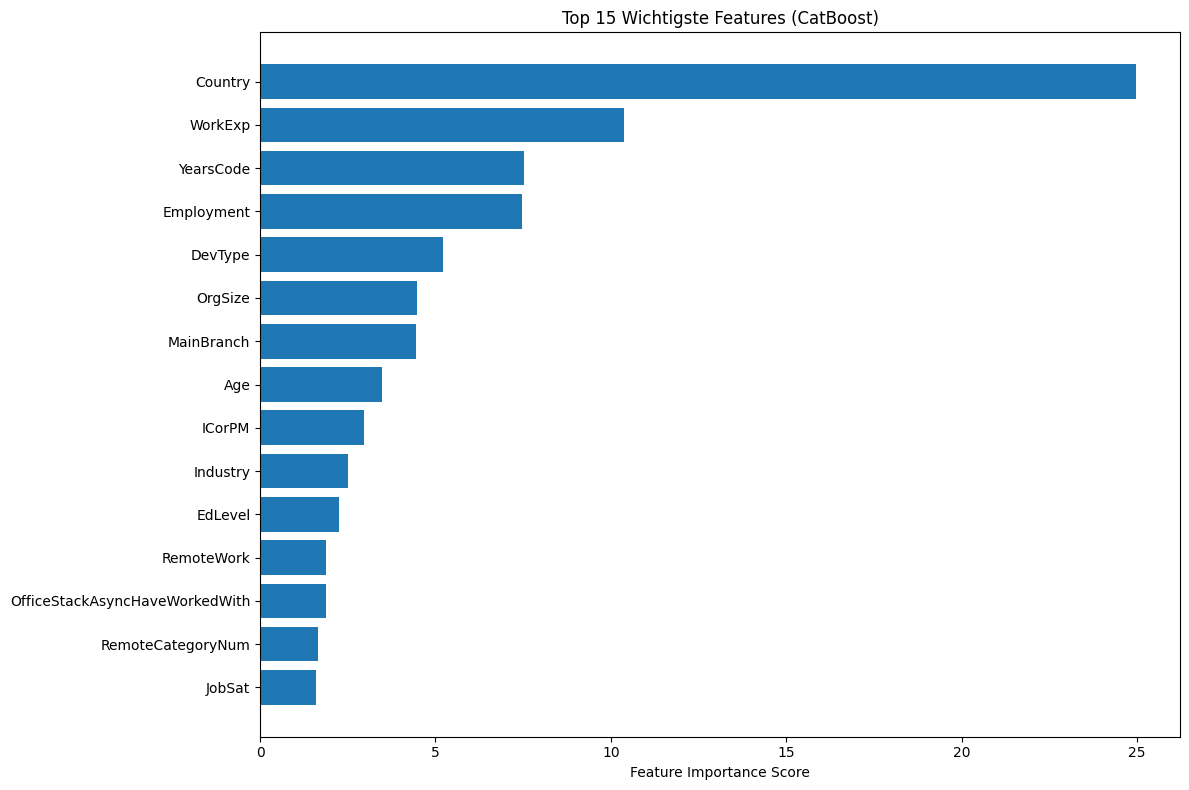

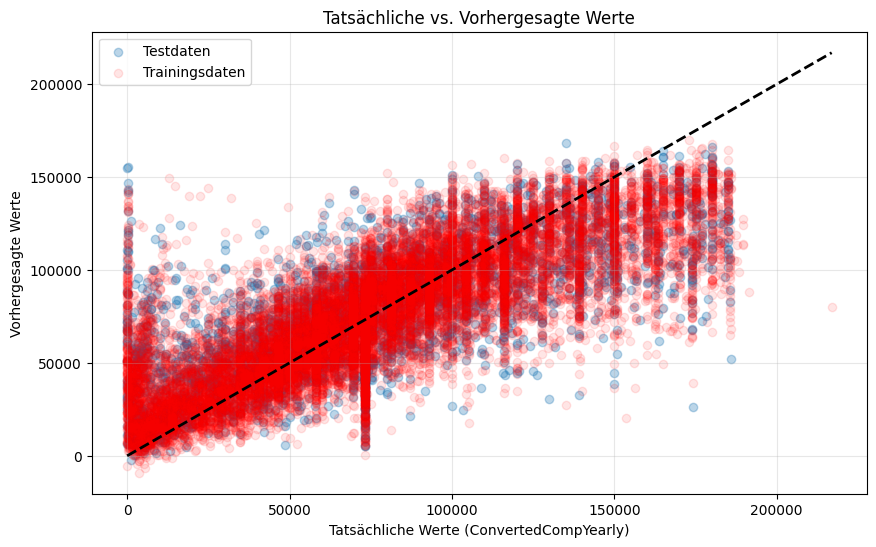

In [4]:
# CatBoost Modell mit automatischer Handhabung kategorialer Features
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# 1. Daten vorbereiten
# Wähle alle Spalten außer der Zielvariable und entferne zusätzlich 'CompTotal'
X = df.drop(['ConvertedCompYearly', 'CompTotal', "Currency", "ConvertedCompTotal"], axis=1)
y = df['ConvertedCompYearly'].fillna(df['ConvertedCompYearly'].median())

# 2. Identifiziere kategoriale Spalten
categorical_features = [col for col in X.columns if X[col].dtype == 'object']

# 3. Fülle fehlende Werte
# Für kategoriale Spalten: Fülle mit 'MISSING'
for col in categorical_features:
    X[col] = X[col].fillna('MISSING').astype(str)

# Für numerische Spalten: Fülle mit Median
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col] = X[col].fillna(X[col].median())

# 4. Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Konvertiere kategoriale Spalten zu Kategorien
for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# 6. CatBoost Modell initialisieren
cat_model = CatBoostRegressor(
    iterations=1000,                # Anzahl der Bäume
    learning_rate=0.03,            # Lernrate
    depth=6,                       # Tiefe der Bäume
    cat_features=categorical_features,  # Kategoriale Features
    eval_metric='R2',              # Metrik zur Bewertung
    early_stopping_rounds=50,      # Frühes Stoppen bei keiner Verbesserung
    random_seed=42,
    verbose=100,                   # Zeigt Fortschritt an
    task_type='CPU',               # Kann auf 'GPU' geändert werden
    loss_function='RMSE'           # Verlustfunktion
)

print("Trainiere CatBoost Modell...")

# 7. Modell trainieren
cat_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=True,                    # Zeigt Trainingsfortschritt
    use_best_model=True,
    silent=True                   # Unterdrückt die Ausgabe während des Trainings
)

# 8. Vorhersagen machen
y_pred_train = cat_model.predict(X_train)
y_pred_test = cat_model.predict(X_test)

# 9. Modell evaluieren
def evaluate_model(y_true, y_pred, set_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{set_name} Set Evaluation:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"R² Score: {r2:.4f}")

# 10. Ergebnisse ausgeben
evaluate_model(y_train, y_pred_train, "Training")
evaluate_model(y_test, y_pred_test, "Test")

# 11. Feature Importance anzeigen
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cat_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 wichtigste Features:")
print(feature_importance.head(10).to_string())

# 12. Feature Importance visualisieren
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'][:15][::-1], 
         feature_importance['Importance'][:15][::-1])
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Wichtigste Features (CatBoost)')
plt.tight_layout()
plt.show()

# 13. Vorhersagen vs. tatsächliche Werte plotten
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, label='Testdaten')
plt.scatter(y_train, y_pred_train, alpha=0.1, color='red', label='Trainingsdaten')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Tatsächliche Werte (ConvertedCompYearly)')
plt.ylabel('Vorhergesagte Werte')
plt.title('Tatsächliche vs. Vorhergesagte Werte')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
